In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os 
import json

In [24]:
from numpy.fft import fft2, ifft2, fftshift, ifftshift

# <span style="color:#AE74D4"> Development and testing ideas for BGFR of QSM pipelines </span> </br>

In [ ]:
img = nib.load(r"/Users/mclogar/msc_data/exvivo_sc_qsm/seb_processing/sub-01/fm_tests/test_custom1/clean_B0.nii")
data = img.get_fdata()

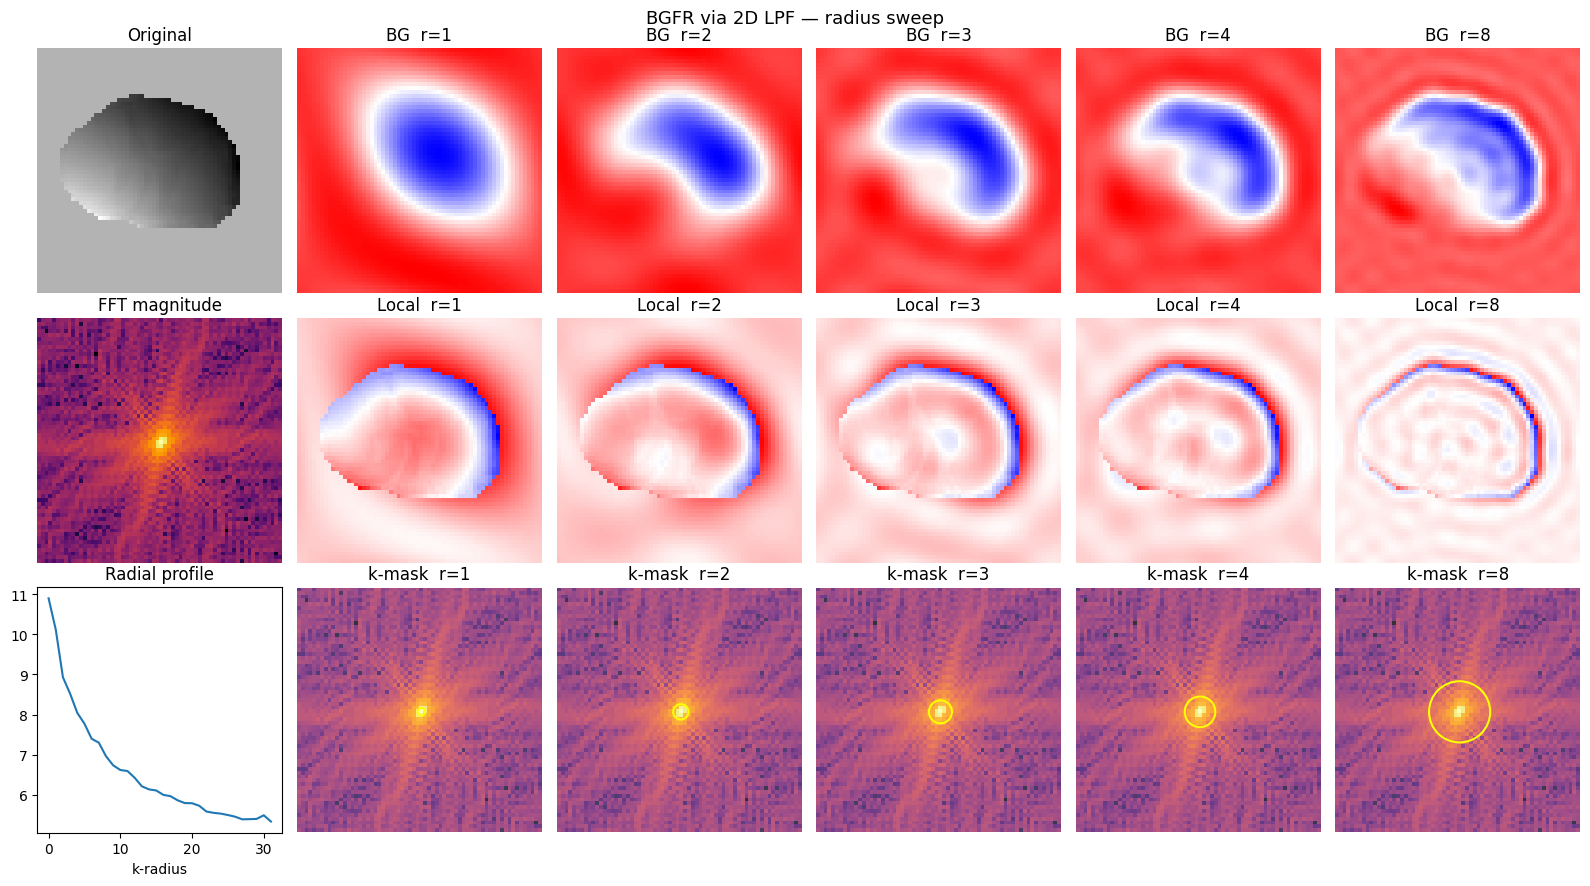

In [7]:
# Doing LPF for BGFR as 3D methods don't work well on a single slice
from scipy.ndimage import gaussian_filter
d = data[:, :, 0] if data.ndim == 3 else data
N = d.shape[0]  # 64

# First we want tos ee the frequency component:
F     = np.fft.fft2(d)
Fshift = np.fft.fftshift(F)          # center DC component
mag   = np.log1p(np.abs(Fshift))     # log magnitude for display

# Now, we can show a filter radius:
cx, cy = N // 2, N // 2 # Centering coordinates
yy, xx = np.ogrid[:N, :N] # Grid 
R_map  = np.sqrt((xx - cx)**2 + (yy - cy)**2).astype(int) # Simple radius eq.
max_r  = N // 2 
profile = np.array([np.log1p(np.abs(Fshift[R_map == r])).mean()
                    for r in range(max_r)]) 

# ── LPF BGFR for multiple radii ───────────────────────────────────────────────
radii = [1, 2, 3, 4, 8]

fig, axes = plt.subplots(3, len(radii) + 1, figsize=(16, 9))

# column 0: original data + FFT + radial profile
axes[0, 0].imshow(d, cmap='gray'); axes[0, 0].set_title('Original')
axes[1, 0].imshow(mag, cmap='inferno'); axes[1, 0].set_title('FFT magnitude')
axes[2, 0].plot(profile); axes[2, 0].set_xlabel('k-radius'); axes[2, 0].set_title('Radial profile')

for col, r in enumerate(radii, start=1):
    # 1. build circular LPF mask in k-space (unshifted coords)
    mask = (R_map <= r).astype(float)             # mask is in shifted coords
    mask_unshift = np.fft.ifftshift(mask)          # undo shift before multiplying

    # 2. apply mask → background field
    F_bg   = F * mask_unshift
    bg     = np.real(np.fft.ifft2(F_bg))           # background (smooth, low-freq)
    local  = d - bg                                 # local field (BGFR output)

    # 3. display
    axes[0, col].imshow(bg, cmap='bwr');
    axes[0, col].set_title(f'BG  r={r}')

    axes[1, col].imshow(local, cmap='bwr');
    axes[1, col].set_title(f'Local  r={r}')

    # k-space mask overlay
    axes[2, col].imshow(mag, cmap='inferno', alpha=0.8)
    circle = plt.Circle((cx, cy), r, color='yellow', fill=False, lw=1.5)
    axes[2, col].add_patch(circle)
    axes[2, col].set_title(f'k-mask  r={r}')

for ax in axes.ravel():
    ax.axis('off')
axes[2, 0].axis('on')   # keep profile plot axes on

plt.suptitle('BGFR via 2D LPF — radius sweep', fontsize=13)
plt.tight_layout()
plt.show()

From PDF's article we see that they applied a 3D Han window LPF with kernel 32^3 to the complex MRI data when one echo was used. </br>
When more echoes are acquire, the LPF  is applied to a reconstructed complex MRI dataset. </br>
Set magnitude equal to the first echo and the phase equal to the unwrapped total field normalized to -pi to pi. </br>
The BG field is estimated from the phase of the result LP-filtered complex image

In [25]:
def hann_lpf_2d_mask(N, kernel_size):
    """
    Square separable 2d Hann-windowed LPF mask in k-space.
    kernel_size: diameter of the Hann window (analogous to the 32 in the paper).
    """
    r = kernel_size // 2
    # 1D Hann window of length kernel_size
    hann_1d = np.hanning(kernel_size)

    # Build 2D Hann window via outer product
    hann_2d = np.outer(hann_1d, hann_1d)

    # Embed in N×N k-space (centered, then ifftshift to unshifted coords)
    mask = np.zeros((N, N))
    cy, cx = N // 2, N // 2 # Centering coordinates
    hs = kernel_size // 2 # half-size
    y0, y1 = cy - hs, cy - hs + kernel_size # vertical bounds in shifted coords
    x0, x1 = cx - hs, cx - hs + kernel_size # horizontal bounds in shifted coords
    # clip to array bounds
    hy0 = max(0, -y0); hy1 = hs*2 - max(0, y1 - N)
    hx0 = max(0, -x0); hx1 = hs*2 - max(0, x1 - N)
    mask[max(0,y0):min(N,y1), max(0,x0):min(N,x1)] = hann_2d[hy0:hy1, hx0:hx1]
    mask /= mask.max()                       # normalize to [0,1]
    return np.fft.ifftshift(mask)            # shift to unshifted k-space coords

In [ ]:
unwrapped_phs_img = nib.load(r"/Users/mclogar/msc_data/exvivo_sc_qsm/seb_processing/sub-01/fm_tests/test_custom1/unwrapped.nii")
unwrapped_phs_data = unwrapped_phs_img.get_fdata() # This data is (x,y,z,n_echoes) but for our ex-vivo z=1

In [26]:
total_field_map_hz_data = nib.load(r"/Users/mclogar/msc_data/exvivo_sc_qsm/seb_processing/sub-01/fm_tests/test_custom1/clean_B0.nii").get_fdata()
# We know the echoes, we can take the first echo: 0.0028s 
TE1 = 0.0028 # seconds
phi_rad = 2 * np.pi * total_field_map_hz_data * TE1 # Convert Hz to radians at TE1


magnitude_data = nib.load(r"/Users/mclogar/msc_data/exvivo_sc_qsm/seb_processing/sub-01/Magn.nii").get_fdata()
# Now get first echo:
mag_echo1 = magnitude_data[:, :, 0, 0]  # ✓ first echo, matches 2D phase


In [27]:
# Inspect phi_rad to see if we need to normalize
print(f"Phase range: {phi_rad.min():.2f} to {phi_rad.max():.2f} radians")

# normalize phase to [-pi, pi]
phi_min = np.nanmin(phi_rad)
phi_max = np.nanmax(phi_rad)

phi_norm = (phi_rad - phi_min) / (phi_max - phi_min)
phi_norm = phi_norm * 2*np.pi - np.pi


Phase range: -1.70 to 0.72 radians


In [ ]:
# Now, form the complex image:
complex_img = mag_echo1 * np.exp(1j * phi_norm)

# LPF: kernel size for Hann LPF (analogous to the 32 in the paper)
ks = 4 
hann_mask_man = hann_lpf_2d_mask(N, ks)
bg_norm = np.angle(ifft2(fft2(complex_img) * hann_mask_man))

bg_field = (bg_norm + np.pi) / (2 * np.pi) # → [0, 1]
bg_field_rad = bg_field * (phi_max - phi_min) + phi_min # → original scale using phi range

# ── Final step: local field ───────────────────────────────────────────────────────
local_field = phase_unwrapped - bg_field # This local field is in radians
# Convert to Hz (assuming TE in seconds)
local_field_Hz = local_phase_rad / (2*np.pi*TE)

NameError: name 'bg_field_rad' is not defined

In [ ]:
# Now create different kernel sizes
kernel_sizes = [8, 16, 24, 32]              # analogous to paper's 32³ in 2D

fig, axes = plt.subplots(4, len(kernel_sizes) + 1, figsize=(16, 12))

# column 0: original data + FFT
cx_map = N // 2
yy, xx = np.ogrid[:N, :N]
R_map = np.sqrt((xx - cx_map)**2 + (yy - cx_map)**2)
F_phase = np.fft.fftshift(np.fft.fft2(p_norm))
mag_log = np.log1p(np.abs(mag_echo1))

axes[0, 0].imshow(phase, cmap='RdBu_r');        axes[0, 0].set_title('Original phase')
axes[1, 0].imshow(mag_log, cmap='inferno');     axes[1, 0].set_title('FFT |phase|')
axes[2, 0].axis('off')
axes[3, 0].axis('off')

for col, ks in enumerate(kernel_sizes, start=1):
    # Build Hann mask
    hann_mask = hann_lpf_mask(N, ks)

    # FFT of complex image → apply mask → IFFT
    F_complex = np.fft.fft2(complex_img)
    F_filtered = F_complex * hann_mask
    img_filtered = np.fft.ifft2(F_filtered)

    # Background field = phase of filtered complex image
    bg_field = np.angle(img_filtered)           # wrapped in [-π, π)

    # Local field = original phase - background
    local_field = phase - bg_field
    # Re-wrap to [-π, π)
    local_field = np.angle(np.exp(1j * local_field))

    # k-space mask for display (shifted)
    mask_display = np.fft.fftshift(hann_mask)

    # ── plots ──
    axes[0, col].imshow(bg_field, cmap='RdBu_r', vmin=-np.pi, vmax=np.pi)
    axes[0, col].set_title(f'BG field  ks={ks}')

    axes[1, col].imshow(local_field, cmap='RdBu_r', vmin=-np.pi, vmax=np.pi)
    axes[1, col].set_title(f'Local field  ks={ks}')

    axes[2, col].imshow(mask_display, cmap='gray')
    axes[2, col].set_title(f'Hann mask  ks={ks}')

    # Overlay mask contour on FFT
    axes[3, col].imshow(mag_log, cmap='inferno', alpha=0.85)
    axes[3, col].contour(mask_display, levels=[0.5], colors='yellow', linewidths=1.2)
    axes[3, col].set_title(f'FFT + mask  ks={ks}')

row_labels = ['Background field', 'Local field (BGFR)', 'Hann LPF mask', 'FFT + mask overlay']
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, labelpad=4)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('HPF BGFR — Hann-windowed complex LPF (kernel size sweep)', fontsize=13)
plt.tight_layout()
plt.show()